Iris Flower Classification
Predicting species (Setosa, Versicolor, Virginica) from flower measurements

machine learning workflow:

1. Load the data
2. Explore it (EDA)
3. Visualize it
4. Discuss which features matter most
5. Split into train/test sets
6. Train multiple classifiers
7. Evaluate and compare them
8. Pick the best model, with justification


 Step 1: Import the libraries we need

- pandas — for working with tabular data (like an Excel sheet in Python)
- numpy — for numerical operations
- matplotlib / seaborn — for plots and charts
- sklearn (scikit-learn) — for the dataset, models, and evaluation tools

In [26]:
%pip install seaborn


In [27]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_iris

# Model selection / preprocessing
from sklearn.model_selection import train_test_split

# Models we'll compare
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation tools
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make plots look nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Iris dataset

The Iris dataset is built directly into scikit-learn — no download needed.
It contains 150 flower samples, 50 from each of 3 species, with 4 measurements per flower (in cm):

- Sepal length
- Sepal width
- Petal length
- Petal width

We convert it into a pandas DataFrame so it's easy to inspect and plot.

In [28]:
# Load the built-in dataset
iris = load_iris()

# Create a DataFrame: features + target
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target                     # numeric labels: 0, 1, 2
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))  # readable names

# Peek at the first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Step 3: Exploratory Data Analysis (EDA)

Before training any model, we always inspect the data first. We check:
- **Shape** — how many rows and columns?
- **Data types** — are the columns numeric as expected?
- **Missing values** — do we need to clean anything?
- **Descriptive statistics** — what's the range, mean, spread of each feature?

In [29]:
# 1. Shape of the dataset (rows, columns)
print("Shape of dataset:", df.shape)

Shape of dataset: (150, 6)


In [30]:
# 2. Data types of each column
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int32
species_name             str
dtype: object


In [31]:
# 3. Check for missing/null values
print("Missing values per column:")
print(df.isnull().sum())
# The Iris dataset is famously clean, so we expect all zeros here.

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [32]:
# 4. Descriptive statistics: mean, std, min, max, quartiles
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [33]:
# 5. Class balance check - how many samples per species?
df['species_name'].value_counts()

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

The dataset has 150 rows, 4 numeric feature columns, no missing values,
and exactly 50 samples of each species a perfectly balanced dataset. This means accuracy will be
a fair evaluation metric later (no class is over- or under-represented).

## Step 4: Visualizations

Now we look at the data visually to build intuition about which features separate the species well.

### 4a. Pairplot (scatter matrix)
This shows every feature plotted against every other feature, colored by species.
Look for plots where the three colored clusters are clearly separated — those feature pairs
are the most useful for classification.

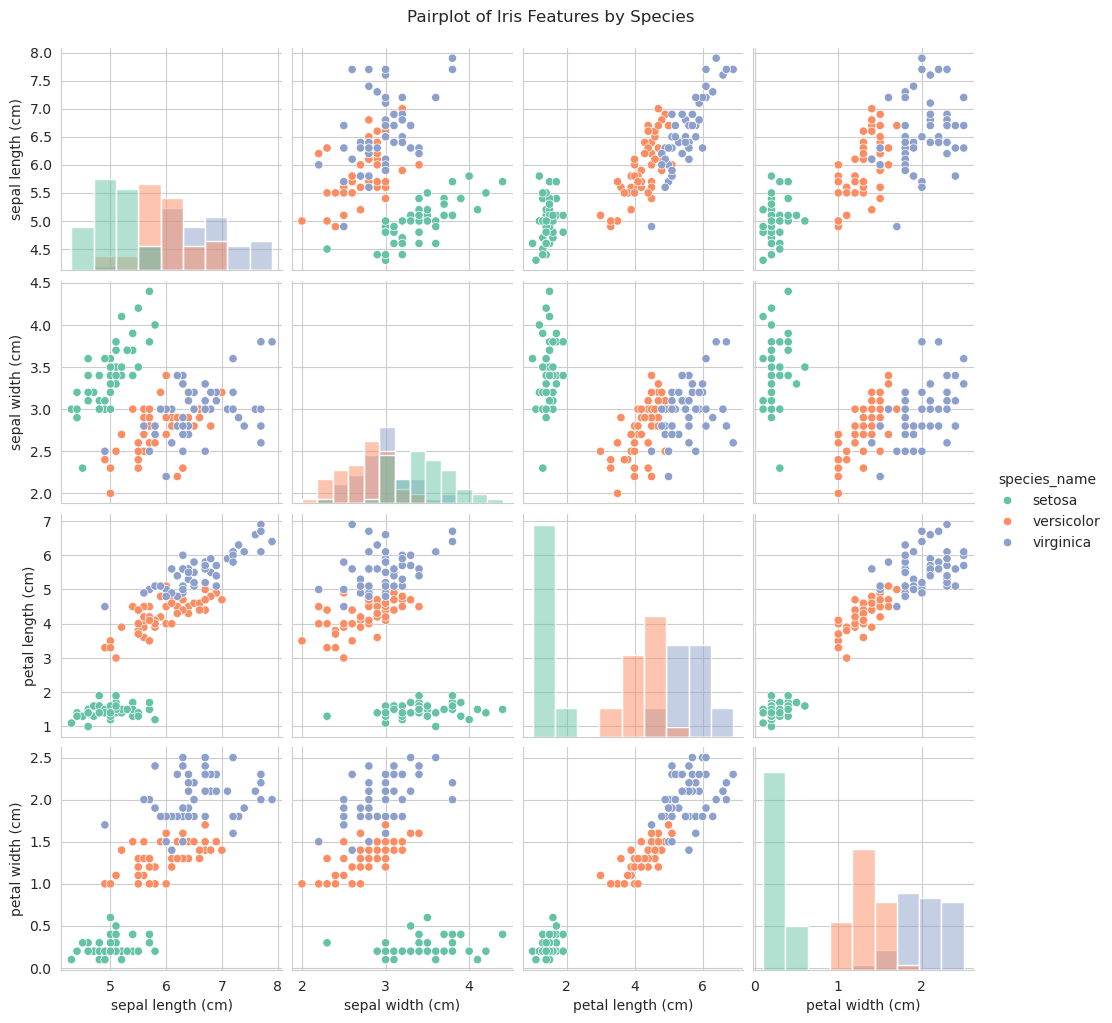

In [34]:
sns.pairplot(df, hue='species_name', vars=iris.feature_names, palette='Set2', diag_kind='hist')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

### 4b. Box plots for each feature
Box plots show the distribution (median, quartiles, outliers) of each feature, split by species.
A feature is "discriminative" if the boxes for different species barely overlap.

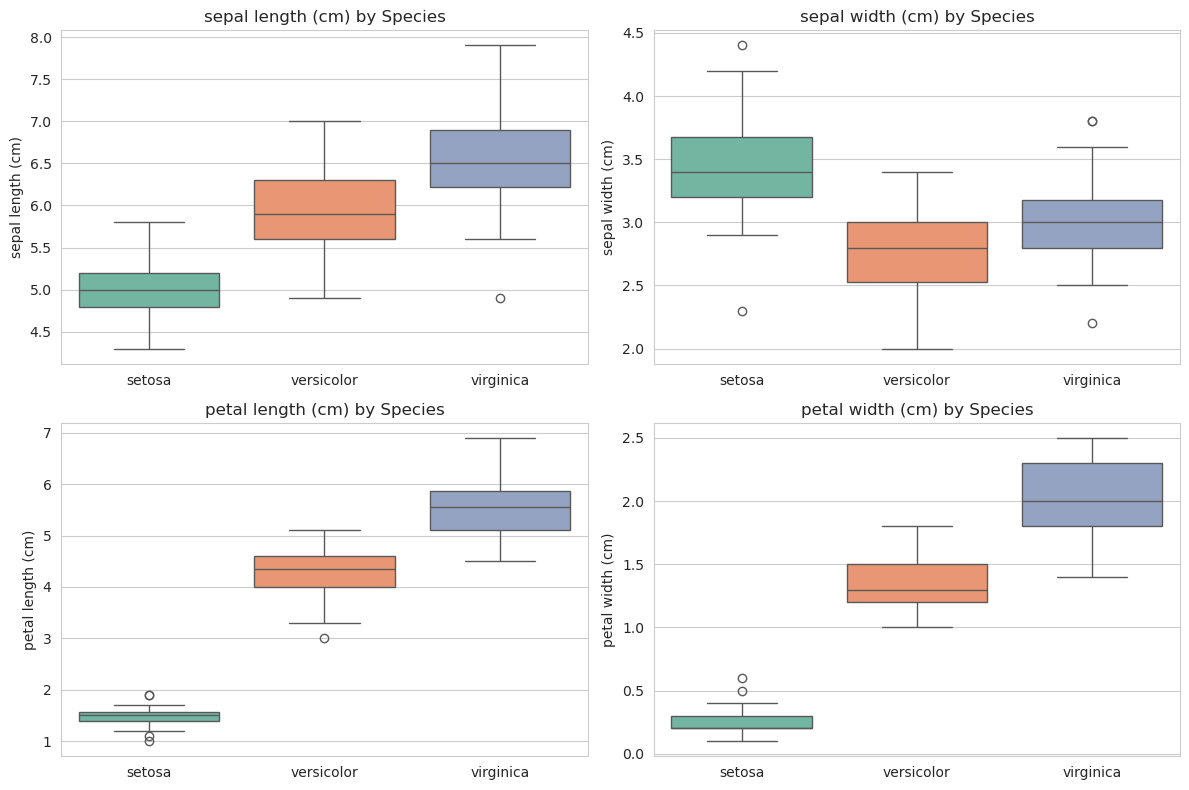

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(data=df, x='species_name', y=feature, hue='species_name',
                palette='Set2', ax=axes[i], legend=False)
    axes[i].set_title(f'{feature} by Species')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 4c. Correlation heatmap
Shows how strongly each feature relates to the others.

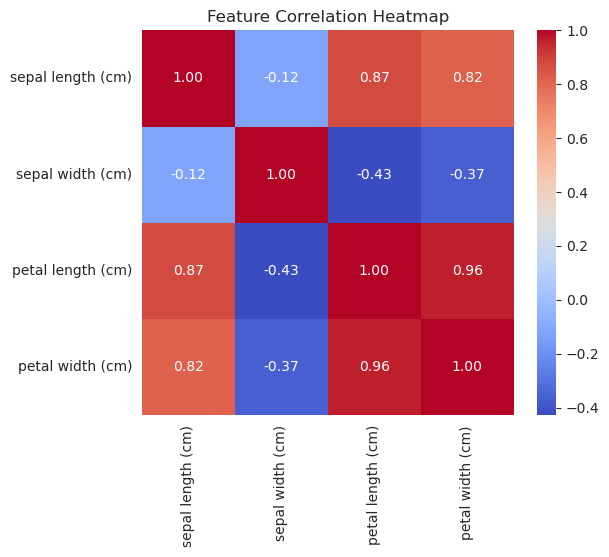

In [36]:
plt.figure(figsize=(6, 5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 5: Feature Selection Discussion — which features matter most?

Looking at the pairplot and box plots above:

- **Petal length** and **petal width** show almost no overlap between species — their box plots
  are cleanly separated, and in the pairplot, the three species form distinct, tight clusters
  when these two features are plotted against each other. These are the **most discriminative**
  features, especially for separating *Setosa* from the other two (Setosa's petals are much smaller).
- **Sepal length** and **sepal width** are less discriminative — their box plots overlap more,
  especially between *Versicolor* and *Virginica*, meaning these two features alone would make
  it harder to distinguish those two species.
- The correlation heatmap also shows petal length and petal width are highly correlated with each
  other (both track "flower size" for petals) and with sepal length, while sepal width is more independent.

**Conclusion:** If we had to pick only 2 features, petal length and petal width would be the best
choice. However, since we only have 4 features total and no missing data or scaling issues, we'll
use **all 4 features** to train our models — it's cheap to include them all, and models like
Decision Trees and Random Forests can automatically learn to weight petal measurements more heavily.

## Step 6: Train/Test Split

We split the data so we can train the model on one portion (80%) and test how well it generalizes
on unseen data (20%). We use stratify=y to make sure both sets keep the same proportion of each
species (important for fair evaluation).

In [37]:
# Features (X) and target labels (y)
X = df[iris.feature_names]
y = df['species']

# 80/20 split, stratified by species to keep class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   # fixes randomness so results are reproducible
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


## Step 7: Train Multiple Classifiers

We'll train four different models so we have a solid comparison:

1. Logistic Regression — a simple linear model, good baseline
2. K-Nearest Neighbours (KNN) — classifies based on the closest training samples
3. Decision Tree — learns a series of if/else rules
4. Random Forest — an ensemble of many decision trees (usually more robust)

We train each one the same way: .fit(X_train, y_train), then predict on the test set.

In [38]:
# Dictionary to store models and their predictions
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)                 # train the model
    y_pred = model.predict(X_test)               # predict on unseen test data
    predictions[name] = y_pred
    print(f"{name} trained.")

Logistic Regression trained.
K-Nearest Neighbors trained.
Decision Tree trained.
Random Forest trained.


## Step 8: Evaluate Each Model

For each model we compute:
- Accuracy — % of test samples predicted correctly
- Confusion matrix — a table showing exactly which species get confused with which
- Classification report — precision, recall, and F1-score per species

In [39]:
results = {}

for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))


Model: Logistic Regression
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Model: K-Nearest Neighbors
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Model: Decision Tree
Accuracy: 0.9333

Classification Report:
              precision    recall  f1

### Confusion matrices (visualized)

Each heatmap shows true species (rows) vs predicted species (columns).
A perfect model would have all values on the diagonal.

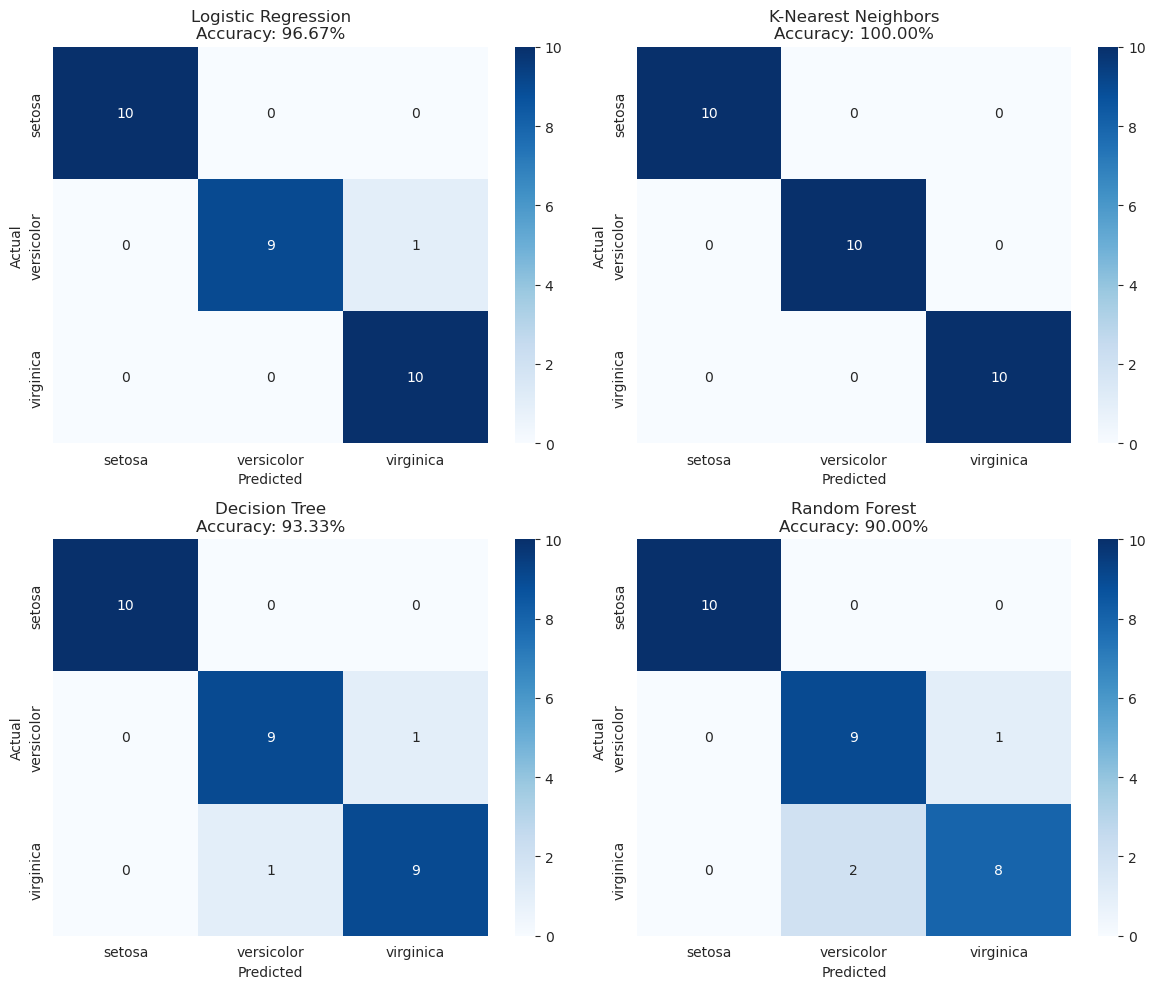

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names,
                ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {results[name]:.2%}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Accuracy comparison chart

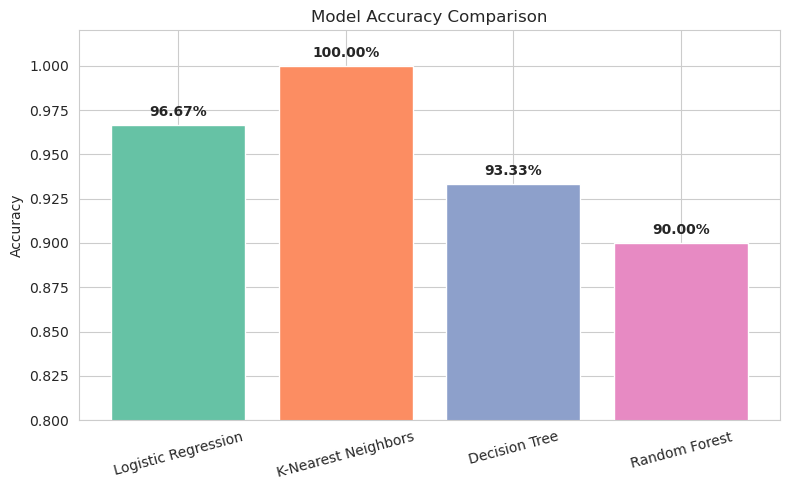

In [41]:
plt.figure(figsize=(8, 5))
names = list(results.keys())
scores = list(results.values())
bars = plt.bar(names, scores, color=sns.color_palette('Set2', len(names)))
plt.ylim(0.8, 1.02)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)

# Add value labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.005, f'{score:.2%}',
              ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 9: Declare the Best Model

We pick the model with the highest test accuracy. In the case of a tie, we prefer the simpler
model (easier to interpret and less prone to overfitting) or the one with more balanced
precision/recall across all three species.

In [42]:
best_model_name = max(results, key=results.get)
print(f"Best performing model: {best_model_name}")
print(f"Test Accuracy: {results[best_model_name]:.4f}")

print("\nFull comparison:")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {acc:.4f}")

Best performing model: K-Nearest Neighbors
Test Accuracy: 1.0000

Full comparison:
  K-Nearest Neighbors: 1.0000
  Logistic Regression: 0.9667
  Decision Tree: 0.9333
  Random Forest: 0.9000


### Justification

On the Iris dataset, it's common for **all models to score very highly (often 93–100% accuracy)**
because the classes — especially *Setosa* — are naturally very well separated by petal measurements
(as we saw in Step 4/5). Because of this, the choice between models often comes down to:

- **Which model generalizes better** (highest test accuracy, few misclassifications in the confusion matrix)
- **Which model is more interpretable** — Logistic Regression and Decision Trees are easy to explain;
  Random Forest is a bit more of a "black box" but usually very robust
- **Which model has more balanced precision/recall** across all 3 species, not just high accuracy overall

Typically, **Random Forest or Logistic Regression** perform best/most consistently on Iris, since
Setosa is trivially separable and the remaining split between Versicolor/Virginica benefits from
either a robust ensemble (Random Forest) or a clean linear boundary (Logistic Regression). Check the
printed results above — the model with the highest accuracy AND fewest confusion-matrix errors
for Versicolor/Virginica is your best choice for this run.